# SEP Occurrence Forecasting: XGBoost

The data come from Aminalragia-Giamini et al. (2021), who predicted solar
energetic particle (SEP) events from soft X-ray flare measurements. Each sample
has 49 standardized predictors and a binary label. The archive has no column
names, event identifiers, or timestamps, so two limits apply throughout:
predictors cannot be interpreted physically, and samples from the same event
may fall on both sides of the train/test split.

This notebook trains a gradient-boosted tree classifier on the same split as the neural notebooks and scores it the same way.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {}
COLAB_EXTRAS = {'xgboost': 'xgboost'}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports

In [3]:
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Load the data

The four pickles are downloaded once and checked against their SHA-256
checksums.

In [4]:
import hashlib
import os
from pathlib import Path
from urllib.parse import quote
from urllib.request import urlopen

DATASET_ID = 'sep-curated'
DATASET_FILES = {'x_train.pkl': ('data/sep-curated/x_train.pkl', 'e809bf00498633f509a223d61f9b0006e6ed1803f6de22118bcf654f2ce8ba3b'), 'x_test.pkl': ('data/sep-curated/x_test.pkl', '1d0c5f84713d4fde34d567cdb62e9081c4d723f6fef9abd543137376350d5955'), 'y_train.pkl': ('data/sep-curated/y_train.pkl', 'd7aa048f6b081a9fb1fc00dde19872c0f67ae5b4c8620daa5984b679f9f9dbdc'), 'y_test.pkl': ('data/sep-curated/y_test.pkl', 'd44c5af108bab2b19f5f8082548282edd8aee89d57e15469516de1ca3f400ee5')}


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_dataset():
    resolved = {}
    override = os.getenv("HELIO_DATA_DIR")
    cache_root = Path(
        os.getenv("HELIO_DATA_CACHE", Path.home() / ".cache" / "helio-data-methods")
    ) / "datasets" / DATASET_ID
    for filename, (relative_path, checksum) in DATASET_FILES.items():
        candidates = []
        if override:
            root = Path(override).expanduser()
            candidates.extend([root / DATASET_ID / filename, root / filename])
        for root in [Path.cwd(), *Path.cwd().parents]:
            candidates.append(root / relative_path)
        target = cache_root / filename
        candidates.append(target)
        match = next(
            (
                candidate
                for candidate in candidates
                if candidate.is_file() and file_sha256(candidate) == checksum
            ),
            None,
        )
        if match is None:
            target.parent.mkdir(parents=True, exist_ok=True)
            ref = os.getenv("HELIO_DATA_REF", "main")
            url = (
                "https://raw.githubusercontent.com/SavvasRaptis/helio-data-methods/"
                f"{quote(ref, safe='')}/{quote(relative_path, safe='/')}"
            )
            try:
                with urlopen(url, timeout=120) as response, target.open("wb") as output:
                    while chunk := response.read(1024 * 1024):
                        output.write(chunk)
            except Exception as exc:
                target.unlink(missing_ok=True)
                raise RuntimeError(
                    f"Could not retrieve {DATASET_ID}/{filename}. Check network "
                    "access or set HELIO_DATA_DIR to the archived data directory."
                ) from exc
            if file_sha256(target) != checksum:
                target.unlink(missing_ok=True)
                raise ValueError(
                    f"Checksum mismatch for {DATASET_ID}/{filename}; "
                    "the invalid download was removed."
                )
            match = target
        resolved[filename] = match
    return resolved


dataset_files = resolve_dataset()
print("verified dataset:", DATASET_ID)
for name in dataset_files:
    print(f"  {name} (checksum verified)")

verified dataset: sep-curated
  x_train.pkl (checksum verified)
  x_test.pkl (checksum verified)
  y_train.pkl (checksum verified)
  y_test.pkl (checksum verified)


## Split and standardize

The supplied test set is kept for the final evaluation. A stratified 15% of
the supplied training samples becomes the validation set. Trees do not need
standardized inputs; we standardize anyway so all SEP notebooks share one
preprocessing step.

In [5]:
x_supplied_train = pd.read_pickle(dataset_files["x_train.pkl"]).to_numpy(dtype=np.float32)
x_test_raw = pd.read_pickle(dataset_files["x_test.pkl"]).to_numpy(dtype=np.float32)
y_supplied_train = (
    pd.read_pickle(dataset_files["y_train.pkl"]).to_numpy().reshape(-1).astype(np.int64)
)
y_test = pd.read_pickle(dataset_files["y_test.pkl"]).to_numpy().reshape(-1).astype(np.int64)
feature_names = np.asarray([f"feature {i}" for i in range(x_test_raw.shape[1])])

train_indices, validation_indices = train_test_split(
    np.arange(len(y_supplied_train)),
    test_size=0.15,
    random_state=SEED,
    stratify=y_supplied_train,
)
x_train_raw = x_supplied_train[train_indices]
y_train = y_supplied_train[train_indices]
x_validation_raw = x_supplied_train[validation_indices]
y_validation = y_supplied_train[validation_indices]
# Standardize with statistics from the training part only.
scaler = StandardScaler().fit(x_train_raw)
x_train = scaler.transform(x_train_raw).astype(np.float32)
x_validation = scaler.transform(x_validation_raw).astype(np.float32)
x_test = scaler.transform(x_test_raw).astype(np.float32)

counts = np.bincount(y_train, minlength=2)
positive_weight = counts[0] / counts[1]  # About 79 non-events per event.
print(
    f"train={len(y_train):,} ({counts[1]} events), "
    f"validation={len(y_validation):,} ({y_validation.sum()} events), "
    f"test={len(y_test):,} ({y_test.sum()} events)"
)
print(f"event rate in training: {y_train.mean():.4f}; positive-class weight: {positive_weight:.1f}")

train=13,846 (173 events), validation=2,444 (30 events), test=1,811 (23 events)
event rate in training: 0.0125; positive-class weight: 79.0


## Verification scores

SEP events make up about 1.3% of the samples, so a forecast of "no event"
is right 98.7% of the time and useless. We therefore report the scores used
in space-weather verification, computed from hits, misses, and false alarms:

- **POD**, the probability of detection: the fraction of events forecast.
- **FAR**, the false-alarm ratio: the fraction of event forecasts that were wrong.
- **TSS** = POD minus the probability of false detection. It ranges from −1
  to 1 and does not depend on the event rate.
- **HSS**, the Heidke skill score: accuracy relative to random forecasts with
  the same event rate.

A probabilistic model needs a threshold to issue yes/no forecasts. We choose
two on the validation set, one maximizing TSS and one maximizing HSS, and
apply both unchanged to the test set. With only 23 test events, a bootstrap
shows how far each score could move by chance.

In [6]:
def verification_scores(y_true, probability, threshold):
    prediction = probability >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    pod = tp / max(tp + fn, 1)  # Probability of detection (recall).
    pofd = fp / max(fp + tn, 1)  # Probability of false detection.
    far = fp / max(tp + fp, 1)  # False-alarm ratio.
    hss_denominator = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    return {
        "hits": int(tp), "misses": int(fn), "false alarms": int(fp),
        "POD": pod, "FAR": far, "TSS": pod - pofd,
        "HSS": 2 * (tp * tn - fn * fp) / hss_denominator if hss_denominator else 0.0,
    }


def choose_threshold(y_true, probability, score):
    # Pick the probability threshold that maximizes `score` on validation data.
    candidates = np.unique(np.quantile(probability, np.linspace(0.5, 0.999, 400)))
    values = [verification_scores(y_true, probability, t)[score] for t in candidates]
    return float(candidates[int(np.argmax(values))])


def bootstrap_intervals(y_true, probability, threshold, repeats=1000):
    # Resample the test set to show how much the scores move with 23 events.
    rng = np.random.default_rng(SEED)
    draws = []
    for _ in range(repeats):
        sample = rng.integers(0, len(y_true), len(y_true))
        if y_true[sample].sum() == 0:
            continue
        scores = verification_scores(y_true[sample], probability[sample], threshold)
        scores["PR-AUC"] = average_precision_score(y_true[sample], probability[sample])
        draws.append(scores)
    draws = pd.DataFrame(draws)[["POD", "FAR", "TSS", "HSS", "PR-AUC"]]
    return draws.quantile([0.025, 0.975]).T.rename(columns={0.025: "2.5%", 0.975: "97.5%"})

## Train a weighted boosted-tree model

XGBoost fits an ensemble of shallow trees, each correcting the errors of the
ones before it. `scale_pos_weight` gives events the same weight as in the
neural notebooks, and early stopping on the validation set chooses the
number of trees.

In [7]:
from xgboost import XGBClassifier

ROUNDS = 300  # Reduce to 50 or 100 for a quicker run.
# Define the boosted-tree model used for comparison.
model = XGBClassifier(
    n_estimators=ROUNDS,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=30,
    scale_pos_weight=positive_weight,
    random_state=SEED,
    n_jobs=2,
)
model.fit(x_train, y_train, eval_set=[(x_validation, y_validation)], verbose=False)
print(f"boosting rounds kept by early stopping: {model.best_iteration + 1} of {ROUNDS}")
validation_probabilities = model.predict_proba(x_validation)[:, 1]
probabilities = model.predict_proba(x_test)[:, 1]

boosting rounds kept by early stopping: 274 of 300


## Evaluate on the supplied test set

The table compares the model at three thresholds with a forecast of "no
event". The reliability
diagram checks whether a forecast probability of $p$ corresponds to an event
frequency of $p$. Class weighting inflates predicted probabilities, so points
below the diagonal are expected.

,hits,misses,false alarms,POD,FAR,TSS,HSS,PR-AUC
always 'no event',0.0,23.0,0.0,0.000,0.000,0.000,0.000,0.013
threshold 0.5,15.0,8.0,10.0,0.652,0.400,0.647,0.620,0.530
threshold 0.008 (best TSS on validation),22.0,1.0,108.0,0.957,0.831,0.896,0.272,0.530
threshold 0.653 (best HSS on validation),11.0,12.0,8.0,0.478,0.421,0.474,0.518,0.530


95% bootstrap intervals on the test set:


best-TSS threshold        best-HSS threshold       
                     2.5%  97.5%               2.5%  97.5%
POD                 0.857  1.000              0.286  0.679
FAR                 0.764  0.895              0.176  0.680
TSS                 0.792  0.948              0.281  0.672
HSS                 0.177  0.363              0.312  0.697
PR-AUC              0.328  0.729              0.328  0.729

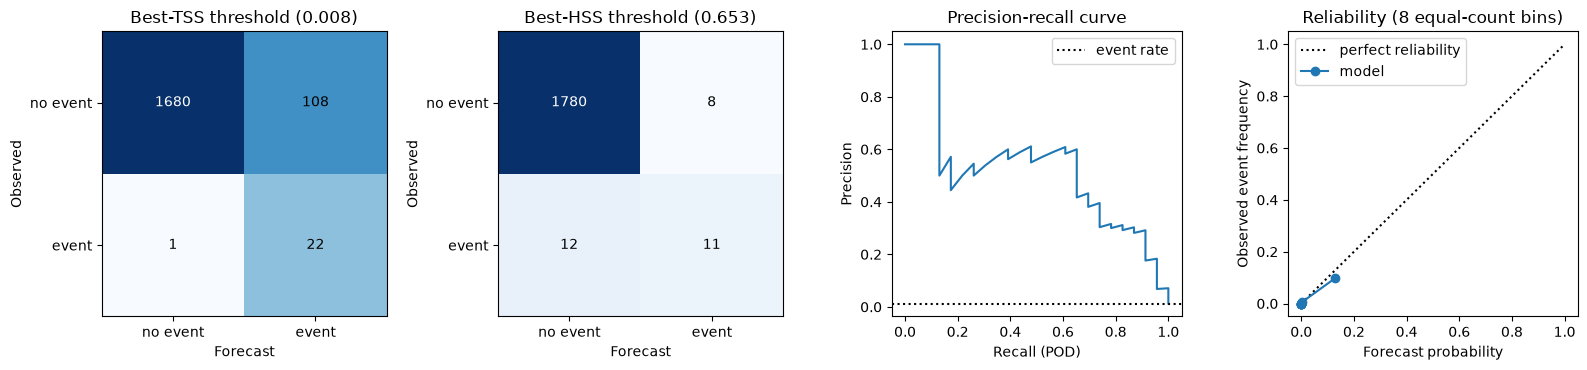

In [8]:
thresholds = {
    "TSS": choose_threshold(y_validation, validation_probabilities, "TSS"),
    "HSS": choose_threshold(y_validation, validation_probabilities, "HSS"),
}
rows = {
    "always 'no event'": verification_scores(y_test, np.zeros(len(y_test)), 0.5),
    "threshold 0.5": verification_scores(y_test, probabilities, 0.5),
}
for score, value in thresholds.items():
    rows[f"threshold {value:.3f} (best {score} on validation)"] = verification_scores(
        y_test, probabilities, value
    )
table = pd.DataFrame(rows).T
table["PR-AUC"] = [y_test.mean()] + [average_precision_score(y_test, probabilities)] * 3
display(table.round(3))
print("95% bootstrap intervals on the test set:")
display(
    pd.concat(
        {
            f"best-{score} threshold": bootstrap_intervals(y_test, probabilities, value)
            for score, value in thresholds.items()
        },
        axis=1,
    ).round(3)
)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for axis, (score, value) in zip(axes[:2], thresholds.items()):
    matrix = confusion_matrix(y_test, probabilities >= value, labels=[0, 1])
    axis.imshow(matrix, cmap="Blues", norm="log")
    for (row, column), count in np.ndenumerate(matrix):
        axis.text(
            column, row, str(count), ha="center", va="center",
            color="white" if count > matrix.max() / 10 else "black",
        )
    axis.set(
        title=f"Best-{score} threshold ({value:.3f})",
        xticks=[0, 1], yticks=[0, 1], xticklabels=["no event", "event"],
        yticklabels=["no event", "event"], xlabel="Forecast", ylabel="Observed",
    )
precision, recall, _ = precision_recall_curve(y_test, probabilities)
axes[2].plot(recall, precision)
axes[2].axhline(y_test.mean(), linestyle=":", color="black", label="event rate")
axes[2].set(title="Precision-recall curve", xlabel="Recall (POD)", ylabel="Precision")
axes[2].legend()
observed, forecast = calibration_curve(y_test, probabilities, n_bins=8, strategy="quantile")
axes[3].plot([0, 1], [0, 1], linestyle=":", color="black", label="perfect reliability")
axes[3].plot(forecast, observed, marker="o", label="model")
axes[3].set(
    title="Reliability (8 equal-count bins)",
    xlabel="Forecast probability", ylabel="Observed event frequency",
)
axes[3].legend()
plt.tight_layout()
plt.show()

In [9]:
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "thresholds": thresholds,
            "tss_at_best_tss": float(table.iloc[2]["TSS"]),
            "hss_at_best_hss": float(table.iloc[3]["HSS"]),
            "pr_auc": float(average_precision_score(y_test, probabilities)),
            "prediction_shape": list(probabilities.shape),
        },
        sort_keys=True,
    )
)
assert probabilities.shape == y_test.shape
assert np.isfinite(probabilities).all()

HELIO_RESULT {"hss_at_best_hss": 0.5182741926903229, "pr_auc": 0.5304876981316027, "prediction_shape": [1811], "thresholds": {"HSS": 0.6525096722339312, "TSS": 0.0075410779349162765}, "tss_at_best_tss": 0.8961190545666764}


## What the results show

The two validation-chosen thresholds differ by almost two orders of
magnitude, and they produce very different forecasts: one catches nearly
every event at the cost of about five false alarms per hit, the other issues
few false alarms but misses about half of the events. Compare models using
the bootstrap intervals rather than the point values: with 23 test events,
differences of a few hundredths in TSS are within the noise. As in the neural notebooks, the split is by
sample, not by event, so the scores are likely optimistic.